In [34]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import ta
import warnings
warnings.filterwarnings('ignore')
import sys
sys.path.append('/home/jack/Dev/candles-bot/scripts')

import importlib
import smc_features
importlib.reload(smc_features)
from smc_features import (
    set_dark_theme, add_rsi_ribbon,
    add_smc_features, add_confirmation_features,
    add_kill_zones_forex, compute_zones,
    plot_smc_chart
)

# Importer aussi la fonction graphique depuis module5
# (on va la déplacer dans smc_features.py plus tard)

set_dark_theme()
print("Fonctions SMC importées !")

# Configuration dark mode
plt.rcParams.update({
    'figure.facecolor' : '#0d1117',
    'axes.facecolor'   : '#0d1117',
    'axes.edgecolor'   : '#30363d',
    'axes.labelcolor'  : '#8b949e',
    'text.color'       : '#e6edf3',
    'xtick.color'      : '#8b949e',
    'ytick.color'      : '#8b949e',
    'grid.color'       : '#21262d',
    'grid.linewidth'   : 0.5,
    'figure.dpi'       : 120,
})

# Test téléchargement EUR/USD
print("Téléchargement EUR/USD...")

# Daily — biais HTF
df_1d = yf.download("EURUSD=X", start="2020-01-01",
                    interval='1d', progress=False)
df_1d.columns = [col[0] for col in df_1d.columns]

# 4H — confirmation MTF
df_4h = yf.download("EURUSD=X", period="729d",
                    interval='4h', progress=False)
df_4h.columns = [col[0] for col in df_4h.columns]

# 1H — entrées LTF
df_1h = yf.download("EURUSD=X", period="729d",
                    interval='1h', progress=False)
df_1h.columns = [col[0] for col in df_1h.columns]

print(f"Daily : {len(df_1d)} bougies — "
      f"{df_1d.index[0].date()} → {df_1d.index[-1].date()}")
print(f"4H    : {len(df_4h)} bougies — "
      f"{df_4h.index[0].date()} → {df_4h.index[-1].date()}")
print(f"1H    : {len(df_1h)} bougies — "
      f"{df_1h.index[0].date()} → {df_1h.index[-1].date()}")

# Vérifier la qualité des données
print(f"\nPrix actuel EUR/USD : {df_1d['Close'].iloc[-1]:.5f}")
print(f"Range journalier moyen : "
      f"{(df_1d['High']-df_1d['Low']).mean()*10000:.0f} pips")

Fonctions SMC importées !
Téléchargement EUR/USD...
Daily : 1645 bougies — 2020-01-01 → 2026-04-28
4H    : 4359 bougies — 2023-07-12 → 2026-04-28
1H    : 17246 bougies — 2023-07-12 → 2026-04-28

Prix actuel EUR/USD : 1.17151
Range journalier moyen : 69 pips


In [35]:
def add_kill_zones_forex(df):
    """
    Kill Zones EUR/USD en UTC
    Forex tourne 24h/5j — Kill Zones basées sur sessions

    Asian KZ     : 00h-03h UTC  — range, liquidité créée
    London Open  : 07h-10h UTC  — plus puissante EUR/USD
    NY Open      : 13h-16h UTC  — deuxième plus puissante
    London Close : 15h-17h UTC  — clôture positions London
    NY Close     : 20h-22h UTC  — clôture journée
    """
    df = df.copy()

    try:
        hour = df.index.hour

        df['kz_asian']      = ((hour >= 0)  & (hour < 3)).astype(int)
        df['kz_london']     = ((hour >= 7)  & (hour < 10)).astype(int)
        df['kz_ny']         = ((hour >= 13) & (hour < 16)).astype(int)
        df['kz_london_cls'] = ((hour >= 15) & (hour < 17)).astype(int)
        df['kz_ny_cls']     = ((hour >= 20) & (hour < 22)).astype(int)

        # In Kill Zone = London ou NY Open
        df['in_kill_zone']  = (
            df['kz_london'] | df['kz_ny']
        ).astype(int)

        # Multiplicateur de confiance
        df['kz_multiplier'] = 1.0
        df.loc[df['kz_london']==1,     'kz_multiplier'] = 3.0
        df.loc[df['kz_ny']==1,         'kz_multiplier'] = 2.5
        df.loc[df['kz_london_cls']==1, 'kz_multiplier'] = 2.0
        df.loc[df['kz_ny_cls']==1,     'kz_multiplier'] = 1.5
        df.loc[df['kz_asian']==1,      'kz_multiplier'] = 0.5

        # Session courante
        df['session'] = 'offmarket'
        df.loc[df['kz_asian']==1,      'session'] = 'asian'
        df.loc[df['kz_london']==1,     'session'] = 'london'
        df.loc[df['kz_ny']==1,         'session'] = 'newyork'
        df.loc[df['kz_london_cls']==1, 'session'] = 'london_close'
        df.loc[df['kz_ny_cls']==1,     'session'] = 'ny_close'

    except AttributeError:
        # Données daily — pas d'heure
        df['kz_london']    = 0
        df['kz_ny']        = 0
        df['in_kill_zone'] = 0
        df['kz_multiplier']= 1.0
        df['session']      = 'daily'

    return df

# Appliquer sur les 3 timeframes
df_1d = add_kill_zones_forex(df_1d)
df_4h = add_kill_zones_forex(df_4h)
df_1h = add_kill_zones_forex(df_1h)

# Stats Kill Zones 1H
print("Kill Zones EUR/USD (1H) :")
print(f"  Asian        (00-03h) : {df_1h['kz_asian'].sum():5d} bougies")
print(f"  London Open  (07-10h) : {df_1h['kz_london'].sum():5d} bougies ← principale")
print(f"  NY Open      (13-16h) : {df_1h['kz_ny'].sum():5d} bougies")
print(f"  London Close (15-17h) : {df_1h['kz_london_cls'].sum():5d} bougies")
print(f"  NY Close     (20-22h) : {df_1h['kz_ny_cls'].sum():5d} bougies")
print(f"\n  Total Kill Zones      : {df_1h['in_kill_zone'].sum():5d} bougies")
print(f"  Multiplicateur max    : {df_1h['kz_multiplier'].max():.1f}x (London)")

Kill Zones EUR/USD (1H) :
  Asian        (00-03h) :  2180 bougies
  London Open  (07-10h) :  2172 bougies ← principale
  NY Open      (13-16h) :  2169 bougies
  London Close (15-17h) :  1446 bougies
  NY Close     (20-22h) :  1451 bougies

  Total Kill Zones      :  4341 bougies
  Multiplicateur max    : 3.0x (London)


In [36]:
importlib.reload(smc_features)
from smc_features import (
    set_dark_theme, add_rsi_ribbon,
    add_smc_features, add_confirmation_features,
    add_kill_zones_forex, compute_zones,
    plot_smc_chart
)

# Recharger les données proprement
df_1d = yf.download("EURUSD=X", start="2020-01-01",
                    interval='1d', progress=False)
df_1d.columns = [col[0] for col in df_1d.columns]

df_4h = yf.download("EURUSD=X", period="729d",
                    interval='4h', progress=False)
df_4h.columns = [col[0] for col in df_4h.columns]

df_1h = yf.download("EURUSD=X", period="729d",
                    interval='1h', progress=False)
df_1h.columns = [col[0] for col in df_1h.columns]

# Appliquer toutes les features
for name, df in [('1D', df_1d), ('4H', df_4h), ('1H', df_1h)]:
    print(f"\nTraitement {name}...")

df_1d = add_kill_zones_forex(df_1d)
df_1d = add_rsi_ribbon(df_1d)
df_1d = add_smc_features(df_1d)
df_1d = add_confirmation_features(df_1d)

df_4h = add_kill_zones_forex(df_4h)
df_4h = add_rsi_ribbon(df_4h)
df_4h = add_smc_features(df_4h)
df_4h = add_confirmation_features(df_4h)

df_1h = add_kill_zones_forex(df_1h)
df_1h = add_rsi_ribbon(df_1h)
df_1h = add_smc_features(df_1h)
df_1h = add_confirmation_features(df_1h)

print(f"\nShapes finales :")
print(f"  Daily : {df_1d.shape}")
print(f"  4H    : {df_4h.shape}")
print(f"  1H    : {df_1h.shape}")


Traitement 1D...

Traitement 4H...

Traitement 1H...
  Volume Forex non fiable — proxy ATR utilisé
  Volume Forex non fiable — proxy ATR utilisé
  Volume Forex non fiable — proxy ATR utilisé

Shapes finales :
  Daily : (1576, 45)
  4H    : (4162, 45)
  1H    : (11089, 45)


In [37]:
# Calculer les zones sur les 3 TF
zones_1d = compute_zones(df_1d, max_len_strong=20, max_len_weak=5)
zones_4h = compute_zones(df_4h, max_len_strong=20, max_len_weak=5)
zones_1h = compute_zones(df_1h, max_len_strong=20, max_len_weak=5)

def zone_summary(zones, label):
    total = len(zones)
    if total == 0:
        print(f"{label} : aucune zone")
        return
    mit   = sum(1 for z in zones if z['mitigated'])
    print(f"\n{label} ({total} zones) :")
    for t in ['OB↑','OB↓','FVG↑','FVG↓']:
        n = sum(1 for z in zones if z['type']==t)
        print(f"  {t} : {n:3d} zones")
    print(f"  Mitigées : {mit} ({mit/total*100:.0f}%)")

zone_summary(zones_1d, "Daily")
zone_summary(zones_4h, "4H")
zone_summary(zones_1h, "1H")


Daily (449 zones) :
  OB↑ :   0 zones
  OB↓ :   0 zones
  FVG↑ : 222 zones
  FVG↓ : 227 zones
  Mitigées : 272 (61%)

4H (932 zones) :
  OB↑ :   0 zones
  OB↓ :   0 zones
  FVG↑ : 490 zones
  FVG↓ : 442 zones
  Mitigées : 568 (61%)

1H (2337 zones) :
  OB↑ :   0 zones
  OB↓ :   0 zones
  FVG↑ : 1190 zones
  FVG↓ : 1147 zones
  Mitigées : 1483 (63%)


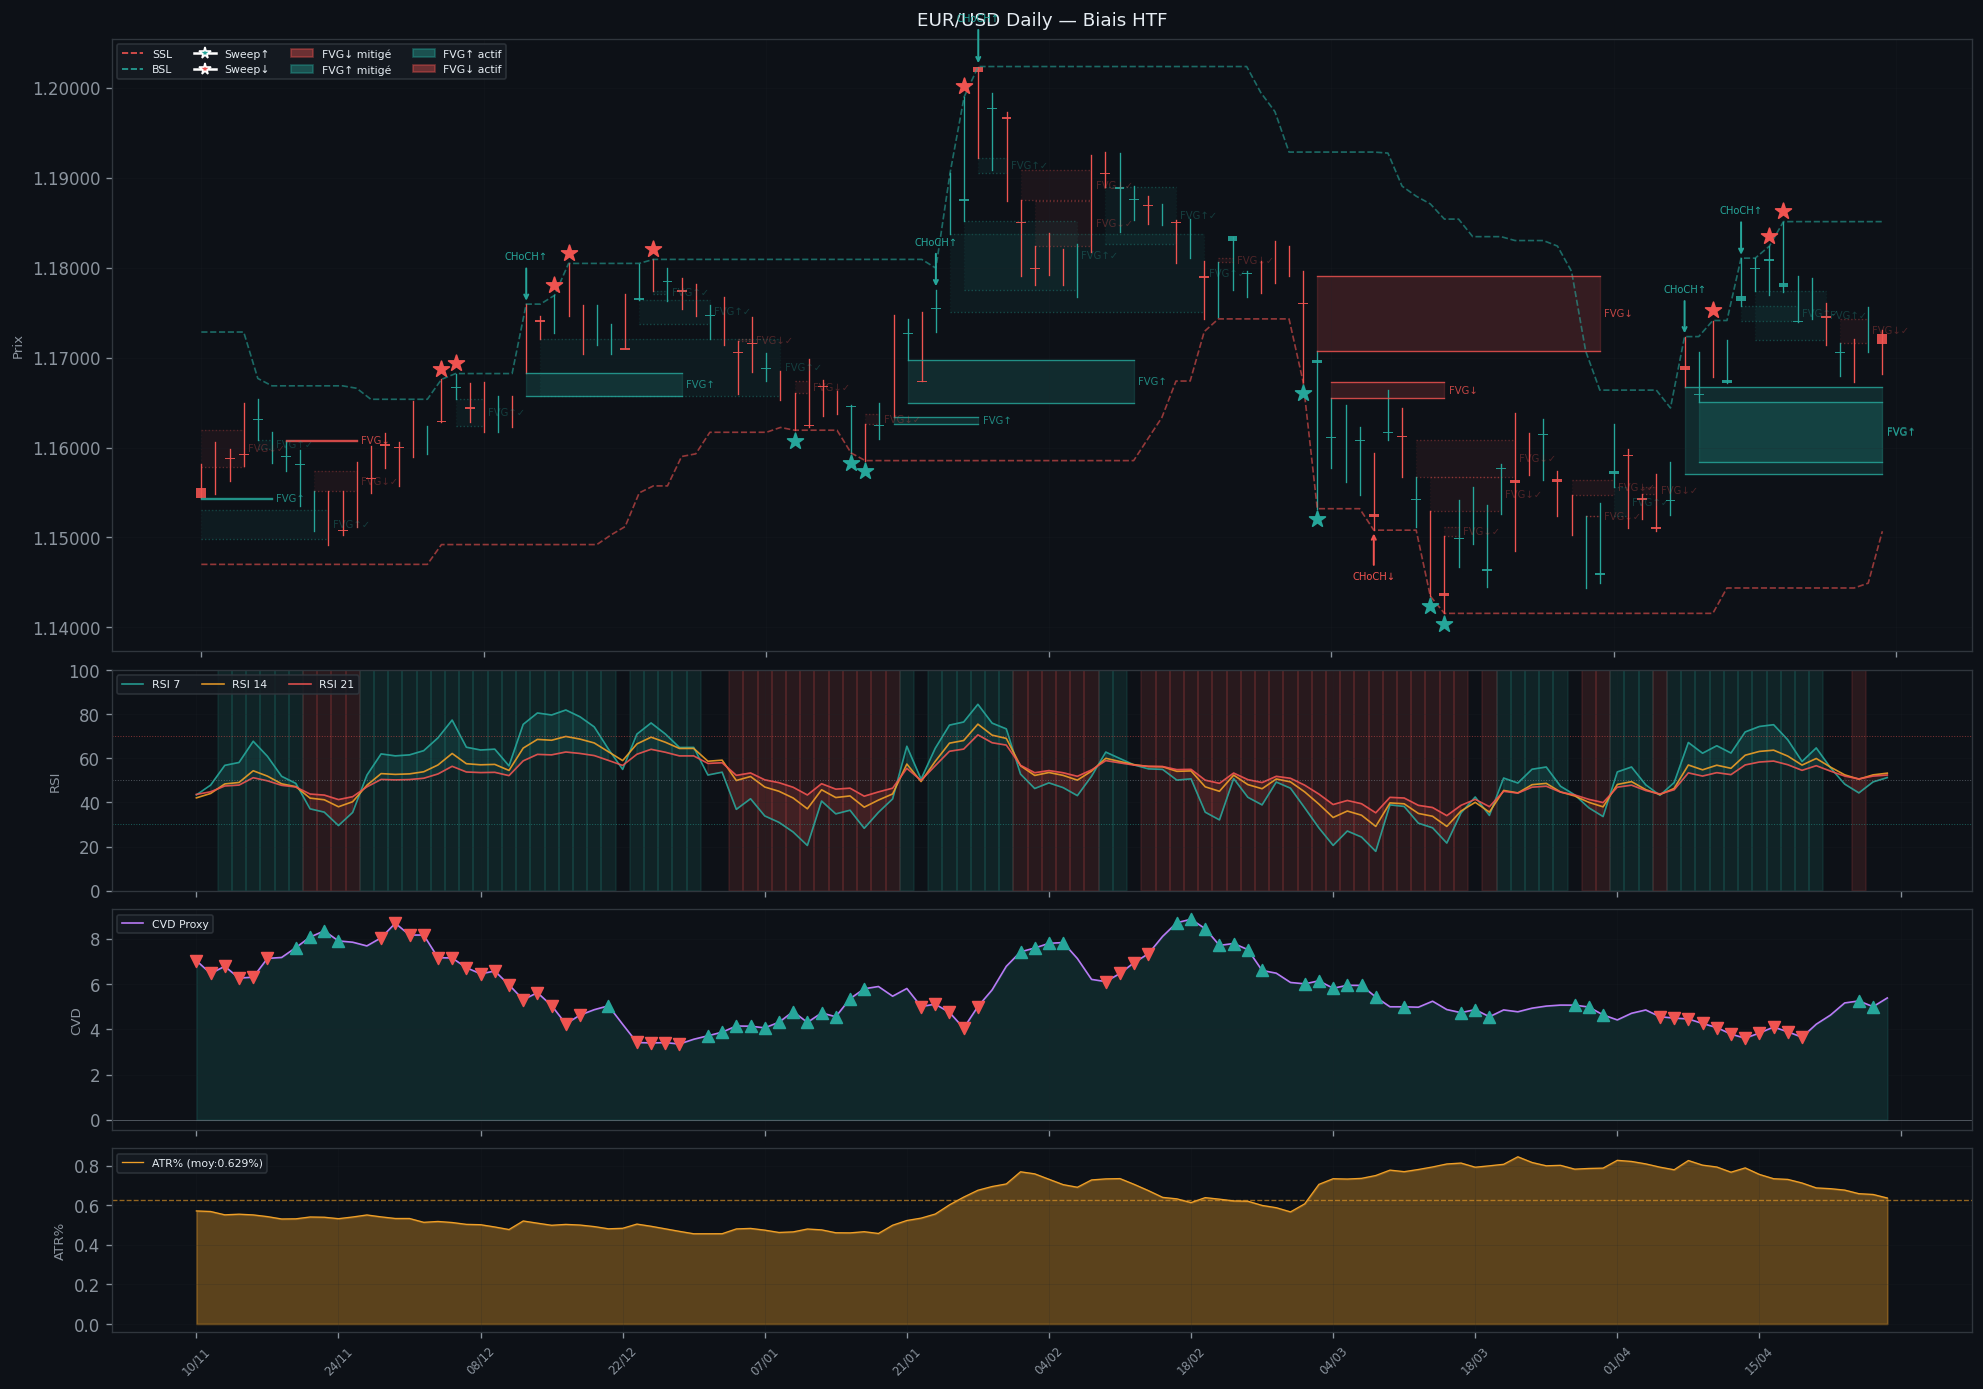

Sauvegardé : EUR/USD Daily — Biais HTF


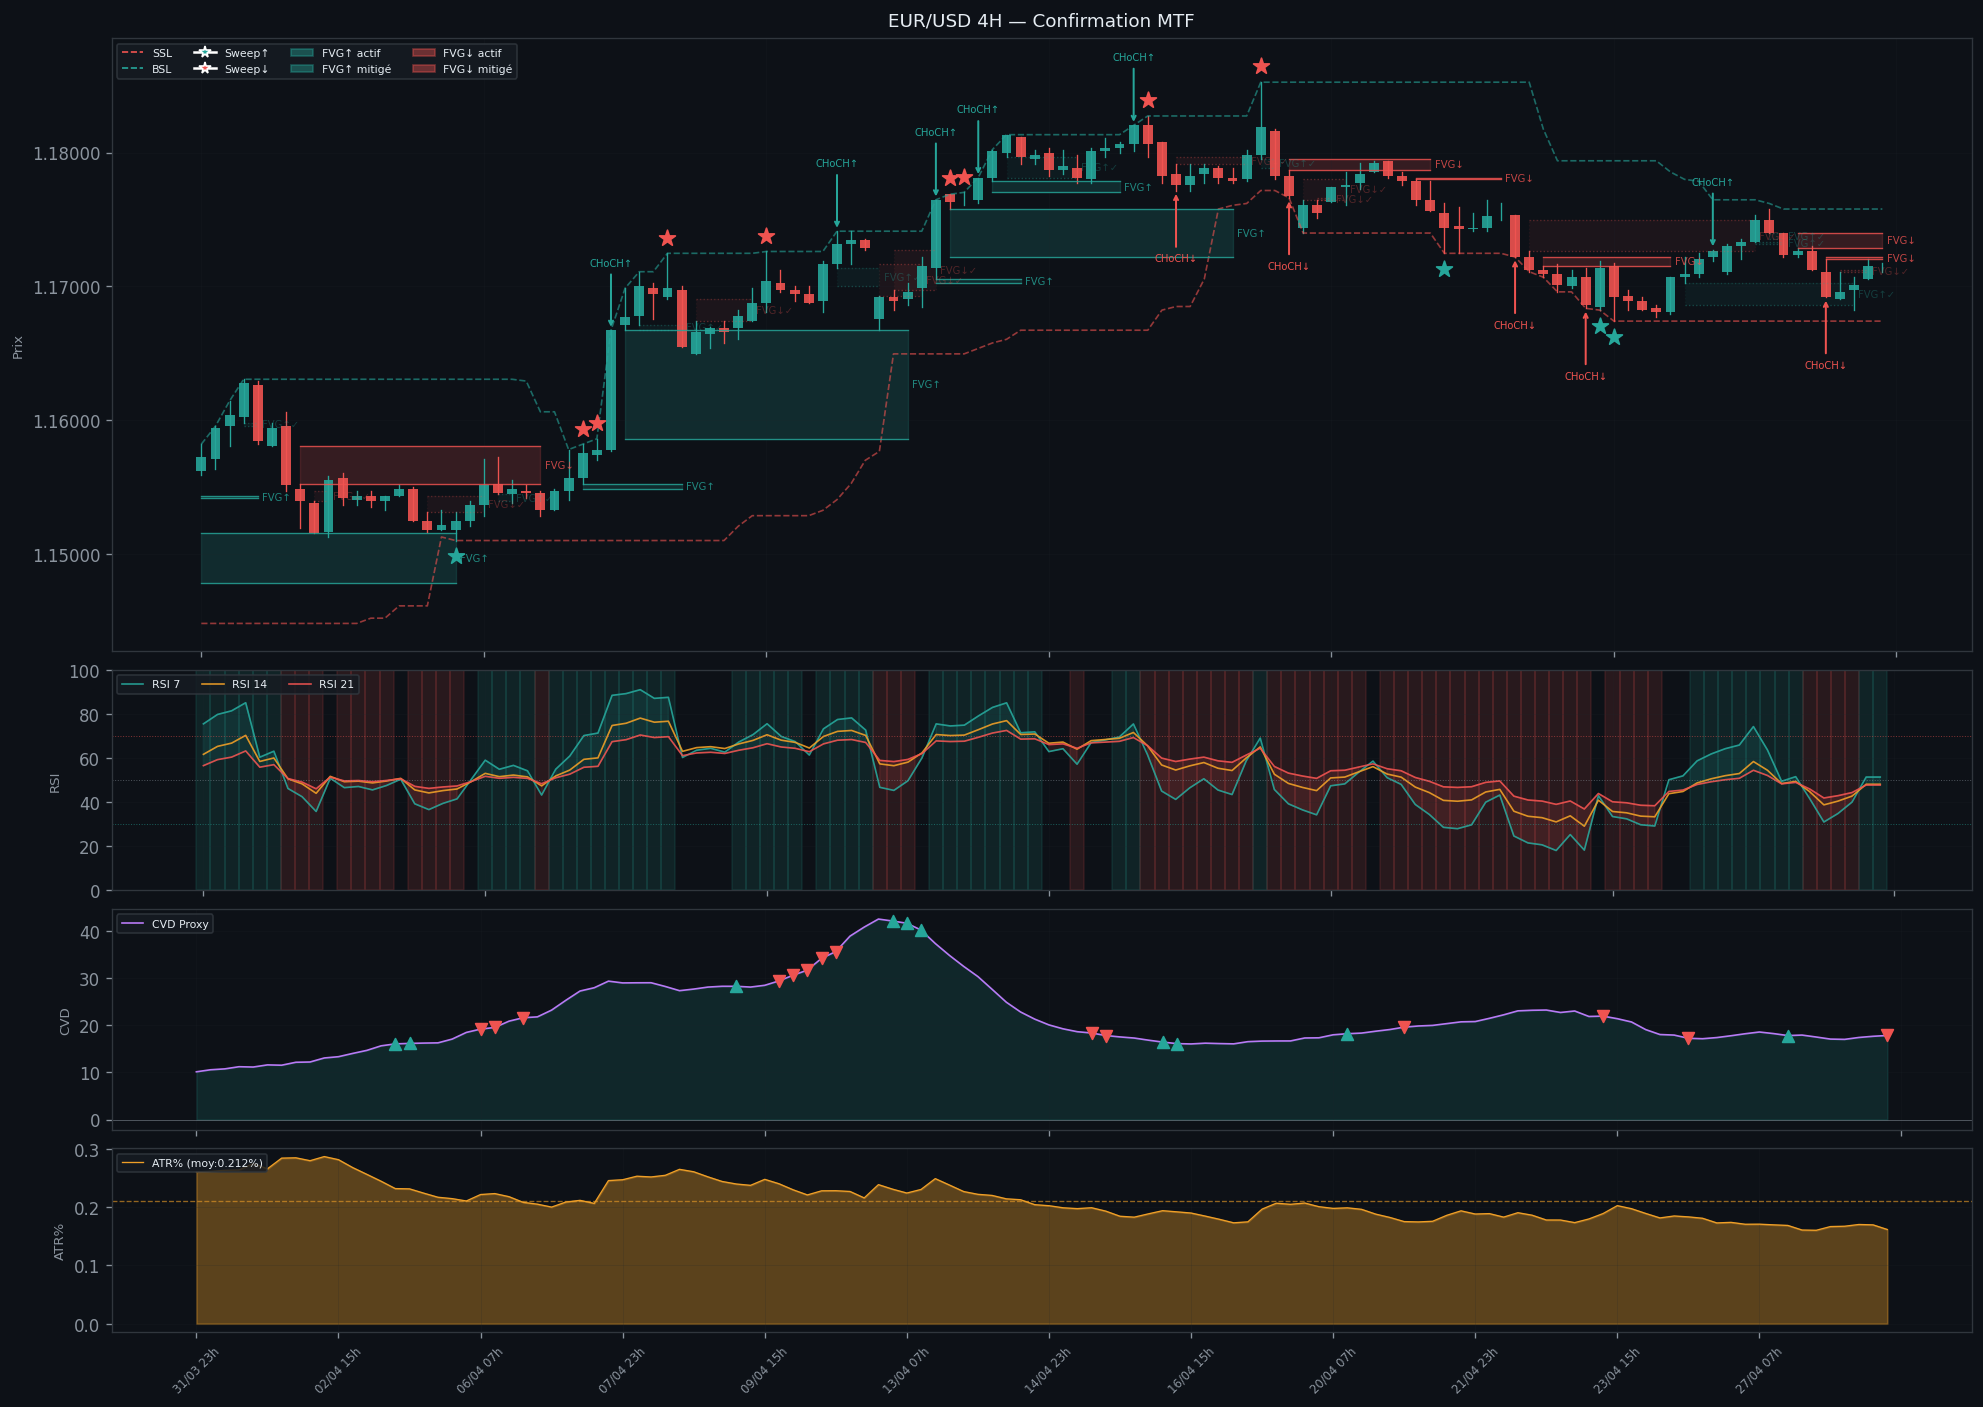

Sauvegardé : EUR/USD 4H — Confirmation MTF


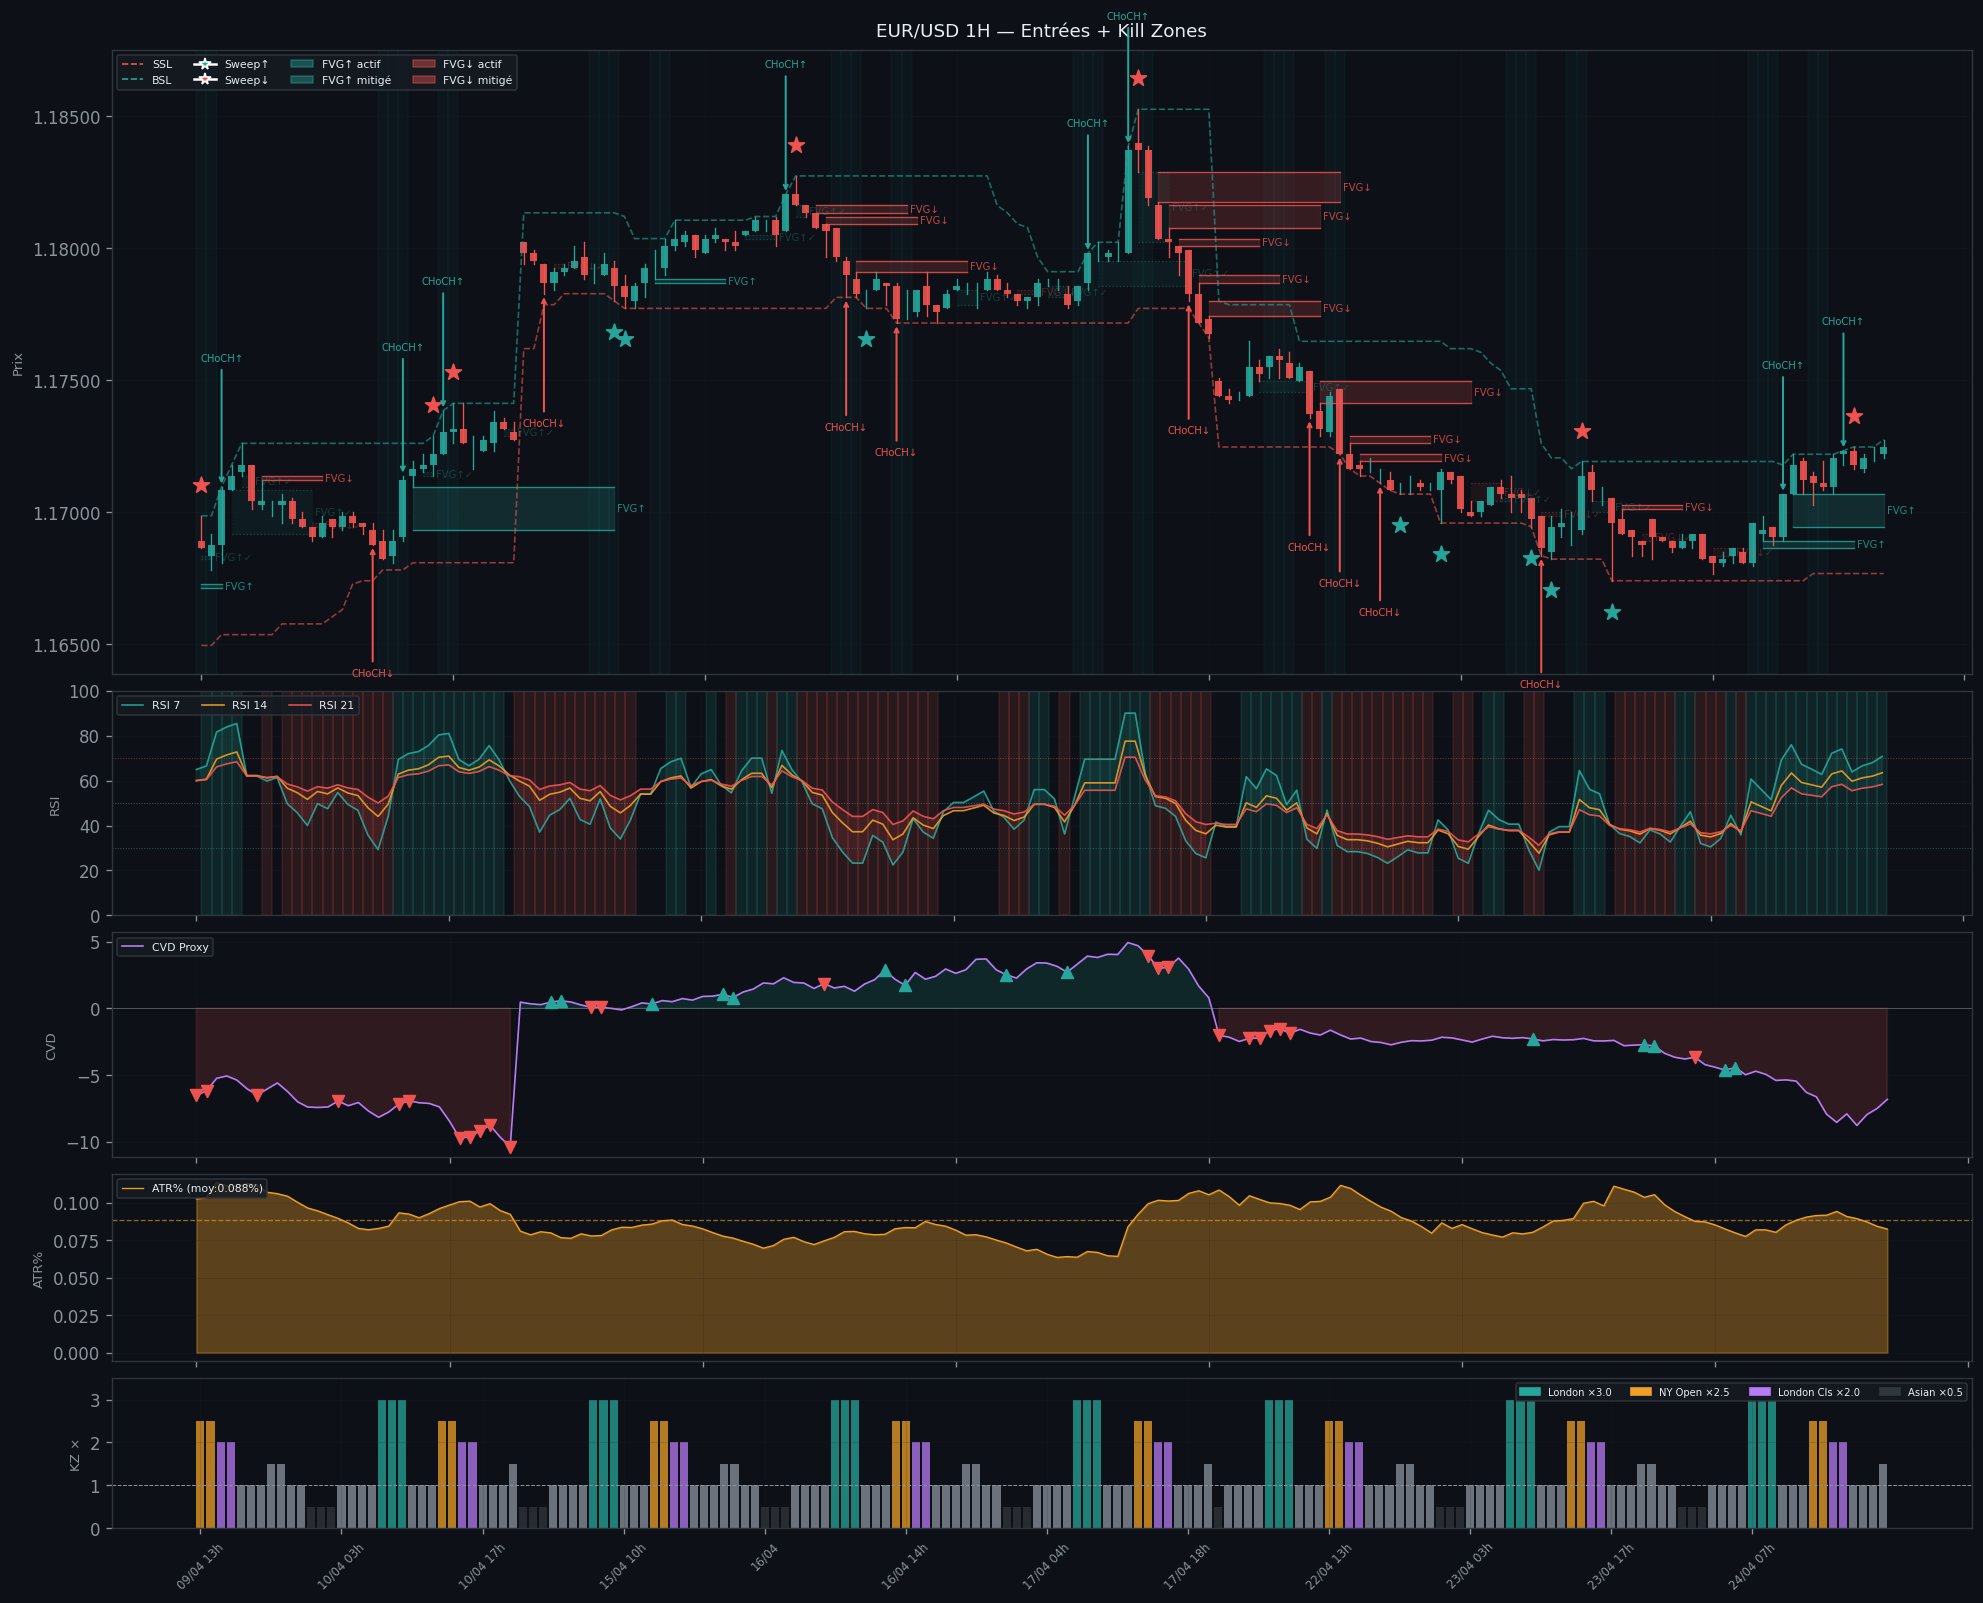

Sauvegardé : EUR/USD 1H — Entrées + Kill Zones


In [38]:
# Daily — biais directionnel
plot_smc_chart(
    df             = df_1d,
    zones          = zones_1d,
    title          = 'EUR/USD Daily — Biais HTF',
    n_bars         = 120,
    show_killzones = False,
    figsize        = (20, 14)
)

# 4H — confirmation
plot_smc_chart(
    df             = df_4h,
    zones          = zones_4h,
    title          = 'EUR/USD 4H — Confirmation MTF',
    n_bars         = 120,
    show_killzones = False,
    figsize        = (20, 14)
)

# 1H — entrées + Kill Zones
plot_smc_chart(
    df             = df_1h,
    zones          = zones_1h,
    title          = 'EUR/USD 1H — Entrées + Kill Zones',
    n_bars         = 168,
    show_killzones = True,
    figsize        = (20, 16)
)

Zones Daily : 449
Zones 4H    : 932
Zones 1H    : 2337


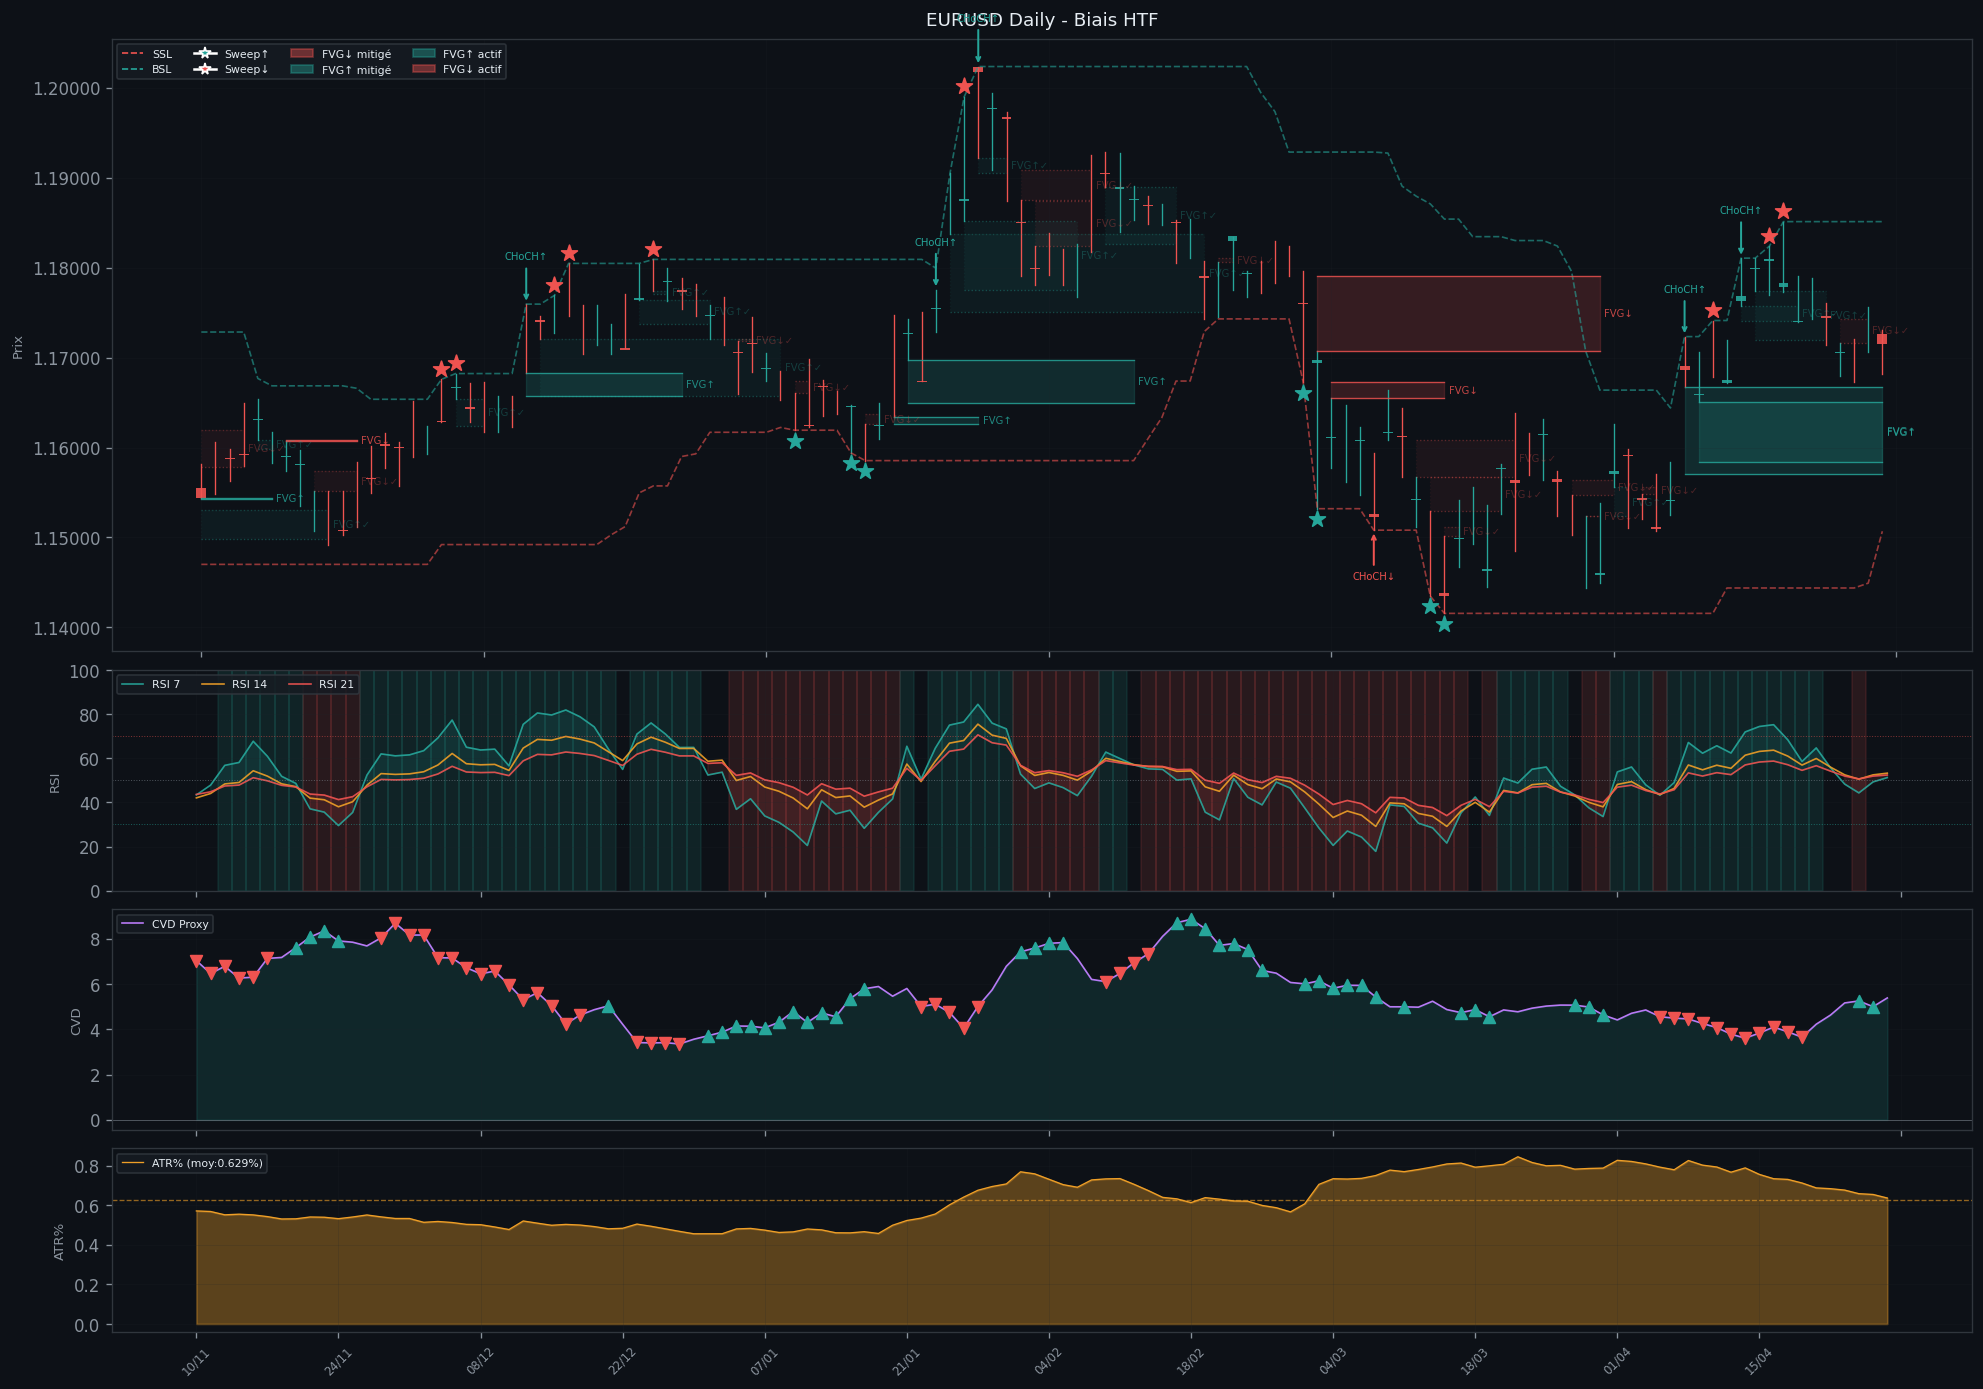

Sauvegardé : EURUSD Daily - Biais HTF


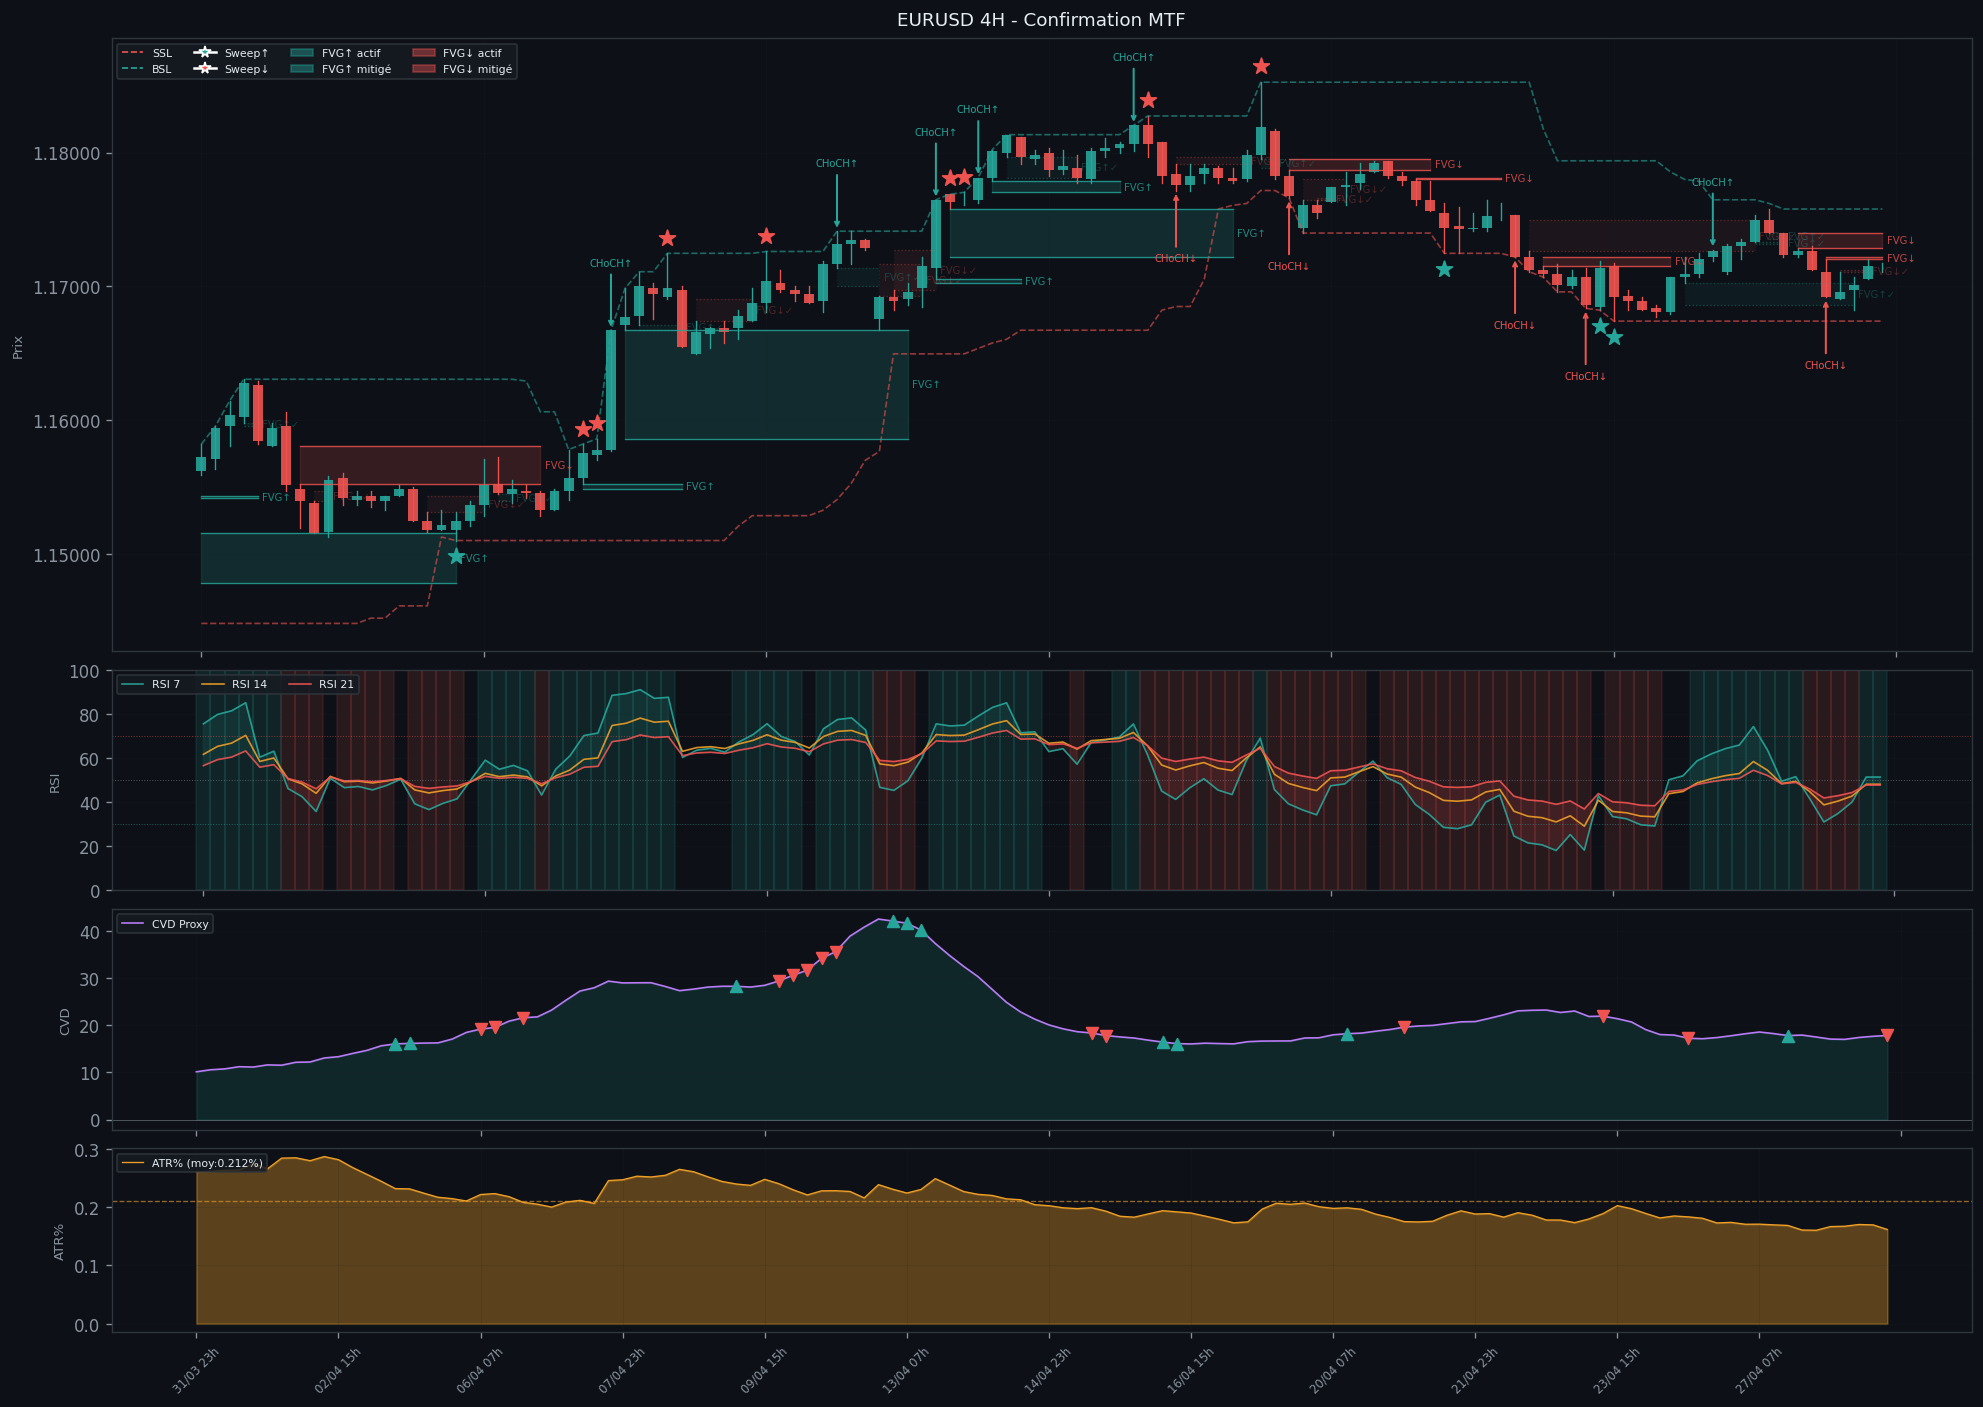

Sauvegardé : EURUSD 4H - Confirmation MTF


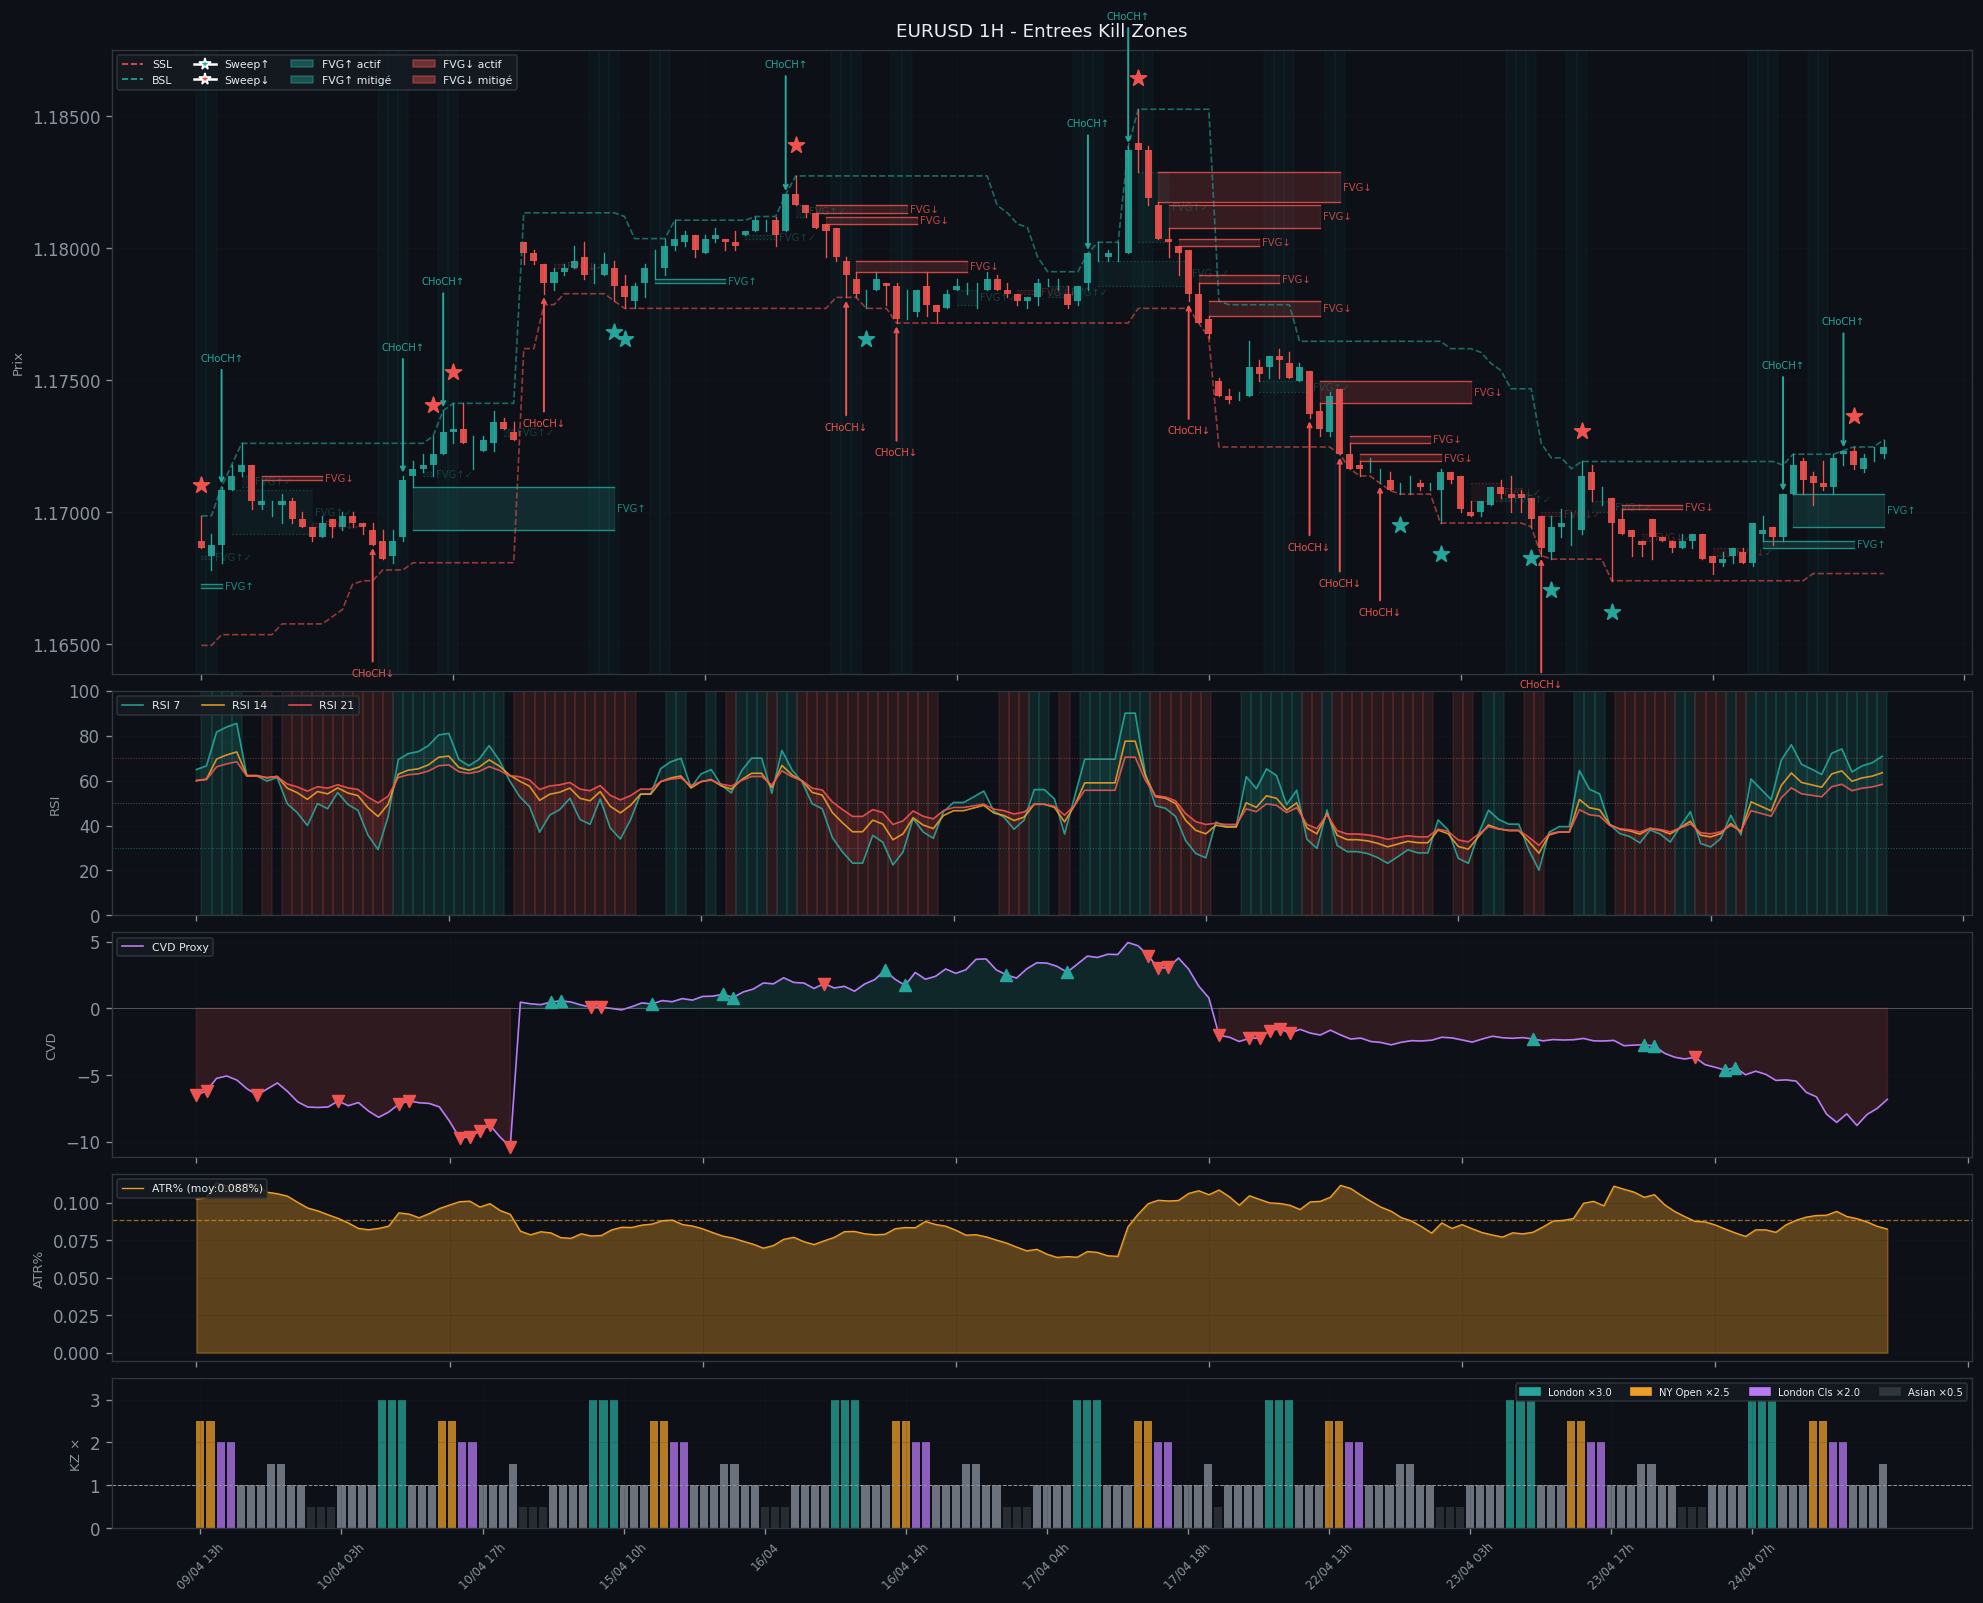

Sauvegardé : EURUSD 1H - Entrees Kill Zones


In [40]:
# Zones dynamiques
zones_1d = compute_zones(df_1d, max_len_strong=20, max_len_weak=5)
zones_4h = compute_zones(df_4h, max_len_strong=20, max_len_weak=5)
zones_1h = compute_zones(df_1h, max_len_strong=20, max_len_weak=5)

print(f"Zones Daily : {len(zones_1d)}")
print(f"Zones 4H    : {len(zones_4h)}")
print(f"Zones 1H    : {len(zones_1h)}")

# Graphique Daily
plot_smc_chart(
    df             = df_1d,
    zones          = zones_1d,
    title          = 'EURUSD Daily - Biais HTF',
    n_bars         = 120,
    show_killzones = False,
    figsize        = (20, 14)
)

# Graphique 4H
plot_smc_chart(
    df             = df_4h,
    zones          = zones_4h,
    title          = 'EURUSD 4H - Confirmation MTF',
    n_bars         = 120,
    show_killzones = False,
    figsize        = (20, 14)
)

# Graphique 1H avec Kill Zones
plot_smc_chart(
    df             = df_1h,
    zones          = zones_1h,
    title          = 'EURUSD 1H - Entrees Kill Zones',
    n_bars         = 168,
    show_killzones = True,
    figsize        = (20, 16)
)

In [33]:
# Vérifier le volume EUR/USD
raw = yf.download("EURUSD=X", start="2020-01-01",
                  interval='1d', progress=False)
raw.columns = [col[0] for col in raw.columns]
print(f"Shape brut : {raw.shape}")
print(f"Volume nul : {(raw['Volume']==0).sum()} jours")
print(f"Volume NaN : {raw['Volume'].isna().sum()} jours")
print(raw[['Close','Volume']].tail(5))

Shape brut : (1645, 5)
Volume nul : 1645 jours
Volume NaN : 0 jours
               Close  Volume
Date                        
2026-04-22  1.174426       0
2026-04-23  1.170604       0
2026-04-24  1.168388       0
2026-04-27  1.170645       0
2026-04-28  1.171509       0
